Build your own recommendation system for products on an e-commerce website like Amazon.com. 

Dataset columns - first three columns are userId, productId, and ratings and the fourth column is timestamp. You can discard the timestamp column as in this case you may not need to use it.

Source - Amazon Reviews data (http://jmcauley.ucsd.edu/data/amazon/).

 

Dataset Link - https://drive.google.com/file/d/1ClBptsK3V5KgKXtK2GSRzFNAW7GnTPDW/view?usp=sharing

 

Please do the analysis based on steps( 1 to 8) as given below  using a NEW python notebook:

Steps -

1. Read and explore the given dataset.  ( Rename column/add headers, plot histograms, find data characteristics)
2. Take a subset of the dataset to make it less sparse/ denser. ( For example, keep the users only who has given 50 or more number of ratings )
3. Split the data randomly into train and test dataset. ( For example, split it in 70/30 ratio)
4. Build Popularity Recommender model.
5. Build Collaborative Filtering model.
6. Evaluate both the models. ( Once the model is trained on the training data, it can be used to compute the error (like RMSE) on predictions made on the test data.) You can also use a different method to evaluate the models.
7. Get top - K ( K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits, we will recommend 5 new products.
8. Summarise your insights.
 

Please Note - 

If you are facing any memory issue while working on this project, create a small subset (Let’s say 10% of data) and work on it.
If you are stuck at the model evaluation part of this project.
Please refer to below links - 

https://surprise.readthedocs.io/en/stable/accuracy.html 

http://surpriselib.com/
Getting started, example
 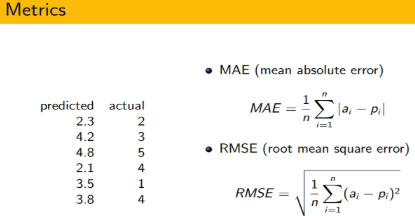

In [1]:
import pandas as pd
import numpy as np

# 1. Read and explore the dataset. (Rename column, plot histograms, find data characteristics)

In [2]:
# Read Amazon Reviews data with proper column names
ratings_pd = pd.read_csv("ratings_Electronics.csv", header=None,
                         names=['userId', 'productId', 'ratings', 'timestamp'],
                         encoding = "ISO-8859-1")
print("Show the shape of the data:", ratings_pd.shape)

# print the head of the data
print("\n\nshow a sample data....")
ratings_pd.head()

Show the shape of the data: (7824482, 4)


show a sample data....


,userId,productId,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [3]:
ratings_pd.drop(columns='timestamp', inplace=True)

In [4]:
# Total unique users 
print("total unique users - ",len(ratings_pd["userId"].unique()))

total unique users -  4201696


In [5]:
# Users with max no of products they have rated
ratings_pd["userId"].value_counts().head()

A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
Name: userId, dtype: int64

In [6]:
# Rating range
print("Rating range in the dataset:", ratings_pd['ratings'].unique())

Rating range in the dataset: [5. 1. 3. 2. 4.]


In [7]:
ratings_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
userId       object
productId    object
ratings      float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


In [8]:
ratings_pd.hist()

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f618e9c3ba8>]],
      dtype=object)

### From the histogram ploting, the ites with 5 ratings are more compared to others

# 2. Take subset of dataset to make it less sparse/more dense. (For example, keep the users only who has given 50 or more number of ratings )

In [9]:
# Create a subser of data which contain users who gave 150 or more number of ratings
rating_150_pd = ratings_pd[ratings_pd['userId'].isin(ratings_pd['userId'].value_counts()[ratings_pd['userId'].value_counts() >= 150].index)]

In [10]:
print("Users who have given lower number of rating above 150:")
rating_150_pd['userId'].value_counts().tail()

Users who have given lower number of rating above 150:


A1EKSETIBS9ETQ    155
A3W4D8XOGLWUN5    153
A17HMM1M7T9PJ1    151
A32O5FZH994CNY    151
A225G2TFM76GYX    150
Name: userId, dtype: int64

In [11]:
print("Users who have given higher number of rating:")
rating_150_pd['userId'].value_counts().head()

Users who have given higher number of rating:


A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
Name: userId, dtype: int64

In [12]:
print("Total number of user who have given number of rating more then 150:", rating_150_pd.shape[0])

Total number of user who have given number of rating more then 150: 21960


In [13]:
# Total unique users finally
print("total unique users - ",len(rating_150_pd["userId"].unique()))

total unique users -  99


In [14]:
# Total unique prodcuts finally
print("total unique prodcuts - ",len(rating_150_pd["productId"].unique()))

total unique prodcuts -  13451


# 3. Split the data randomly into train and test dataset. (For example split it in 70/30 ratio)

In [15]:
from surprise import Dataset,Reader
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(rating_150_pd[['userId', 'productId', 'ratings']], reader)

In [16]:
# Split data to train and test
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=.30,random_state=123)

In [17]:
# The training set will be a type of surprise.trainset.Trainset
type(trainset)

surprise.trainset.Trainset

In [18]:
# Test set will be a list
type(testset)

list

# 4. Build Popularity Recommender model.

In [19]:
# The users ratings.
# This is a dictionary containing lists of tuples of the form ``(item_inner_id, rating)``.
# The keys are user inner ids
user_records = trainset.ur
type(user_records)

collections.defaultdict

In [20]:
# show the item with user inner id 0 and item inner id 1767
user_records[0][10]

(1767, 4.0)

In [21]:
# However the ids are the inner ids and not the raw ids
# raw ids can be obatined as follows
print(trainset.to_raw_uid(0))
print(trainset.to_raw_iid(1767))

A3J8A5L5AF5TX9
B001U02JZ8


In [22]:
rating_150_pd.head()

,userId,productId,ratings
178,A17HMM1M7T9PJ1,0970407998,4.0
631,A3TAS1AG6FMBQW,0972683275,5.0
2162,A5JLAU2ARJ0BO,1400532655,1.0
3383,A3PD8JD9L4WEII,1400699169,5.0
4495,A1ZU55TM45Y2R8,8862936826,2.0


In [23]:
from surprise import KNNWithMeans
from surprise import accuracy

In [24]:
algo = KNNWithMeans(k=50, sim_options={'name': 'pearson', 'user_based': False})
algo.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


### Show 10 most similar items to productId='1400532655'

In [25]:
#Show 10 most similar items to productId='1400532655'
recc = algo.get_neighbors(trainset.to_inner_iid("1400532655"), k=10)
print("Products similar to '1400532655':")
[trainset.to_raw_iid(x) for x in recc]

Products similar to '1400532655':


['B003CKC8W8',
 'B0015DYMVO',
 'B009L946F6',
 'B0013DXVYK',
 'B005MZU0MG',
 'B001JU9NZ8',
 'B004PWKRK2',
 'B008MF3X9K',
 'B00CZ7510K',
 'B0012WXFPM']

## Top 20 popular or recommended products

In [26]:
testset_new = trainset.build_anti_testset()

In [27]:
len(testset_new)

1007100

In [28]:
testset_new[0:5]

[('A3J8A5L5AF5TX9', 'B0015DYMVO', 4.315183450429352),
 ('A3J8A5L5AF5TX9', 'B009L946F6', 4.315183450429352),
 ('A3J8A5L5AF5TX9', 'B0013DXVYK', 4.315183450429352),
 ('A3J8A5L5AF5TX9', 'B005MZU0MG', 4.315183450429352),
 ('A3J8A5L5AF5TX9', 'B001JU9NZ8', 4.315183450429352)]

In [29]:
predictions = algo.test(testset_new[0:10000])

In [30]:
predictions_df = pd.DataFrame([[x.uid, x.iid,x.est] for x in predictions])

In [31]:
# Create a priority bases recomended system for each user
predictions_df.columns = ["userId", "productId","est_rating"]
predictions_df.sort_values(by = ["est_rating"],ascending=False,inplace=True)

### Show the top 20 recommended products

In [32]:
predictions_df.head(20).iloc[:, 1:].reset_index(drop=True)

,productId,est_rating
0,B00008OTDY,5.0
1,B000HJ5N2Y,5.0
2,B00FRMAOIO,5.0
3,B009YCASK2,5.0
4,B000O1FTYC,5.0
5,B002FYL7PG,5.0
6,B002C1B9QY,5.0
7,B0032UJIEY,5.0
8,B000X4UFMQ,5.0
9,B00GRQ8AQM,5.0


In [33]:
# Mkae prediction for a single user
algo.predict(uid="A5JLAU2ARJ0BO",iid="1400532655")

Prediction(uid='A5JLAU2ARJ0BO', iid='1400532655', r_ui=None, est=1, details={'actual_k': 1, 'was_impossible': False})

# 5. Build Collaborative Filtering model.

In [34]:
# Import header files for collaborative filtering based on Matrix factorization SVD
from surprise import SVD
from surprise import accuracy

In [35]:
# Build the model using train dataset
svd_model = SVD(n_factors=50,biased=False)
svd_model.fit(trainset)

In [36]:
# Test with test data set in the trained model
test_pred = svd_model.test(testset)

In [37]:
# compute RMSE
accuracy.rmse(test_pred)

RMSE: 2.1072


2.107163316234656

### The RMSE value is very high, try to grid search and finetune the hyper parameters

In [38]:
from surprise.model_selection import GridSearchCV
param_grid = {'n_factors' : [5,10,15], "reg_all":[0.01,0.02]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3,refit = True)

In [39]:
gs.fit(data)

In [40]:
# get all parameter combinations
gs.param_combinations

[{'n_factors': 5, 'reg_all': 0.01},
 {'n_factors': 5, 'reg_all': 0.02},
 {'n_factors': 10, 'reg_all': 0.01},
 {'n_factors': 10, 'reg_all': 0.02},
 {'n_factors': 15, 'reg_all': 0.01},
 {'n_factors': 15, 'reg_all': 0.02}]

In [41]:
# get best parameters
gs.best_params

{'rmse': {'n_factors': 5, 'reg_all': 0.02}}

In [42]:
# Use the "best model" for prediction
gs_pred = gs.test(testset)

In [43]:
# compute RMSE
accuracy.rmse(gs_pred)

RMSE: 0.7831


0.7831196798672517

##### Now the RMSE value have come down

In [44]:
# Build SVD model using the turned parameters
# Build the model using train dataset
svd_model1 = SVD(n_factors=5, reg_all=0.02)
svd_model1.fit(trainset)

# Test with test data set in the trained model
test_pred = svd_model1.test(testset)
# compute RMSE
accuracy.rmse(test_pred)

RMSE: 0.8941


0.8940724879782815

### Compute a Similarity Matrix of products using correlation

In [45]:
# User featurs
user_factors = svd_model1.pu
user_factors.shape

(99, 5)

In [46]:
# Item features
item_factors = svd_model1.qi
item_factors.shape

(10328, 5)

In [47]:
# Create a correlation matrix of each products
item_sim = np.corrcoef(item_factors)

# Sort the products in terms of max correlation
max_val = (-item_sim).argsort()

In [48]:
item_sim.shape

(10328, 10328)

In [49]:
# Get max 20 correlated prodcuts of each products
topk = pd.DataFrame(max_val[:,0:20])

In [50]:
# create item iid dictionary

all_product = [trainset.to_raw_iid(x) for x in range(0,10328)]
product_iid_dict = dict(zip(range(0,10328), all_product))

In [51]:
topk = topk.replace(product_iid_dict)

In [52]:
topk = topk.rename(columns={0:"products"})
print("Show first 20 products are similar to each prodcuts in the list:")
topk

Show first 20 products are similar to each prodcuts in the list:


,products,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,B003CKC8W8,B002DONEKO,B000LFZ6OE,B000TXZIDM,B000HDL05O,B002FU6KF2,B000LBUBNE,B00C97AF16,B009LB2V3I,B009M3UQ78,B00BX49972,B009XNBFJK,B000NK3H4S,B00007GQLS,B008VV4Z9W,B002RJSSOM,B002LVUIS0,B00003CWFA,B00CEB5QU2,B003O2RVGM
1,B0015DYMVO,B000JJM7S0,B004RFGALC,B004YLCE2S,B00DK2JQOQ,B003D8GAA0,B0002XN69C,B00DJ6AFX4,B003AM87Q4,B002DEMAWM,B002PNEDFS,B003XN24GY,B00009R88X,B0002JY6T0,B0012CDWNC,B003I4FHNA,B000BF185U,B0014EB50K,B003OSTDPI,B009APC0R2
2,B009L946F6,B007K3SB6K,B0008JF0CG,B005QWY3PU,B0007QQK2Y,B007X3VDU8,B004GGWOSK,B003XE3X8Q,B0006OCFFS,B001V9KG0I,B000UF3FT8,B003ULNA3K,B000H6CBA4,B0015DNIOG,B0040IWVBY,B009AOFNU4,B0090Z3QD4,B004KNXO10,B002VUFGRE,B0000AINE1
3,B0013DXVYK,B000A2JXFQ,B000TG4AGU,B00EPAT2VY,B002WQFWTY,B00GMTN96U,B0010XU4IE,B004DI7CWE,B000281Z6I,B000FH658O,B0041O5YHU,B00KU4RD4M,B00BD7L16G,B000083KIH,B00C32E5RC,B00007E7L4,B00007E361,B00005T3EV,B001GUNJPG,B001BT0IEW
4,B005MZU0MG,B001CBLN7K,B005EWB3YG,B008X9ZAR8,B008R7EWF2,B000NH7SZ0,B0018C7FSO,B004H8FNJ4,B0002Y22VE,B00008W2LR,B0093HMKLS,B002Q8HMWS,B0019BJZAA,B00144KS6W,B005K18KJ2,B009XE0K7W,B0027CTQC2,B000068BSC,B00BWH7TIG,B00CXKC7NI
5,B001JU9NZ8,B004CHNKE0,B009YP274O,B001R95IDM,B00K6B7KJM,B006G9VQV6,B007XJUEXY,B000F2BLU6,B002SRIKN2,B00JUI6SV8,B00AY1K50U,B001K7I5ZO,B001NJ0WCS,B000VLZUQM,B005GQTTQO,B001HLF2KO,B0009XVGMO,B00273QXLS,B0002OCF0C,B0014SWPO6
6,B004PWKRK2,B000AY5Y5W,B000VT2E6I,B001ARLQGY,B00004ZCCU,B00005AWCL,B00540XS32,B0093HGD2K,B001GNC7Q0,B00793MIGK,B00005UKBX,B000SKU94E,B005NFG1MS,B0026L7FGI,B000067SNB,B002IC0YLS,B0049MOK92,B00AEK5V82,B00752VKFA,B0042X9LC4
7,B008MF3X9K,B00009NFEP,B007ZHAYL6,B00E60PZFK,B003A0T6YS,B009289F02,B00BTJIJ40,B00009R8B9,B00B99JU5M,B0035FZ11K,B00BEHQKPM,B005OTESFK,B0000W533W,B00G6BQ31W,B00BLX7CAG,B002JP16ZM,B00DWMPM92,B0058SRNZ4,B004YIZWWU,B008U3038I
8,B00CZ7510K,B003TOE4PQ,B0048IATQ0,B00017LSCG,B007DL79FS,B005ARQV6U,B0015A8Y5M,B000V07QBU,B000VZCETO,B003VVXUS4,B002I9L3X4,B0051WAM64,B000OAFYVG,B00J238GV6,B0044YPN0A,B000T9COJ2,B00AQRX7E8,B0009GUDVQ,B00FZ9SM4M,B00170MYIS
9,B0012WXFPM,B00005V9C0,B005ORQ350,B00000J1TX,B0012WDMNC,B00A628QYE,B00006B7DA,B00008RUXO,B0081H8TRA,B00FC2R7ZC,B006GMIMNI,B0064R9H2A,B002IPHIDC,B0007QU6WY,B00KL51I2I,B004V1DAC4,B000EXTXSI,B002SYAQ50,B002SDZGOC,B001DL5RFS


# 6. Evaluate both the models. (Once the model is trained on the training data, it can be used to compute the error (RMSE) on predictions made on the test data.)

In [53]:
# print the total number and the first few elements of testset
print("Total number of elements in testset:", len(testset))
print("Show the first 5 elements in testset:", testset[0:5])

Total number of elements in testset: 6588
Show the first 5 elements in testset: [('A3TAS1AG6FMBQW', 'B00ITI058W', 5.0), ('A3J8A5L5AF5TX9', 'B0028N6VN2', 4.0), ('A36K2N527TXXJN', 'B00EUTKFMK', 5.0), ('A3OXHLG6DIBRW8', 'B001CSCB6U', 4.0), ('A18HE80910BTZI', 'B00CPKLBIS', 4.0)]


## a. RMSE of the priority Recomendation system using KNNWithMeans

In [54]:
# Evalute on test set
test_pred = algo.test(testset)

# Calculate the RMSE of popularity based model
accuracy.rmse(test_pred)

RMSE: 1.0316


1.0315698998891834

## b. RMSE of the Collaborative Recomendation system using SVD

In [55]:
# Test with test data set in the trained model
test_pred = svd_model1.test(testset)
# compute RMSE
accuracy.rmse(test_pred)

RMSE: 0.8941


0.8940724879782815

# 7. Get top - K (K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits,we will recommend 5 new products.

In [56]:
#Considering only the trainset data contained user ids due to execution resourse limitation
testset_new = trainset.build_anti_testset()

### Prediction top 5 recomendations for all the users with KNN method

In [57]:
 predictions = algo.test(testset_new)
 predictions_df = pd.DataFrame([[x.uid, x.iid,x.est] for x in predictions])

In [58]:
 # Create a priority bases recomended system for each user
predictions_df.columns = ["userId", "productId","est_rating"]
predictions_df.sort_values(by = ["userId", "est_rating"],ascending=False,inplace=True)

In [59]:
predictions_df["userId"].unique()

array(['AZMY6E8B52L2T', 'AYB4ELCS5AM8P', 'AWPODHOB4GFWL', 'AVPNQUVZWMDSX',
       'AT6CZDCP4TRGA', 'AT28RL25Q2OLK', 'ARBKYIVNYWK3C', 'AQIJ3ZEEVCIKU',
       'AOEAD7DPLZE53', 'AN81JUYW2SL24', 'ALDAF4VVLFRHP', 'AKT8TGIT6VVZ5',
       'AIJQU979J6UFY', 'AGVWTYW0ULXHT', 'AEWYUPCNDV7HY', 'AEJAGHLC675A7',
       'ADLVFFE4VBT8', 'ABQWMANK4AR63', 'ABDR6IJ93HFIO', 'A6VXZ1EEPRTLV',
       'A6VPK7X53QNAQ', 'A6FIAB28IS79', 'A680RUE1FDO8B', 'A5JLAU2ARJ0BO',
       'A4WEZJOIZIV4U', 'A3W4D8XOGLWUN5', 'A3V7D0LH8L7BG0',
       'A3U41ZL33SS92P', 'A3TAS1AG6FMBQW', 'A3T7V207KRDE2O',
       'A3R4794K2RVU1S', 'A3QNQQKJTL76H0', 'A3PD8JD9L4WEII',
       'A3OXHLG6DIBRW8', 'A3OA4DV4L81N1D', 'A3NHUQ33CFH3VM',
       'A3NEAETOSXDBOM', 'A3LGT6UZL99IW1', 'A3J8A5L5AF5TX9',
       'A3FEGTOLCWXSV4', 'A3EXWV8FNSSFL6', 'A3CW0ZLUO5X2B1',
       'A3CG93783LP0FO', 'A3AYSYSLHU26U9', 'A3A4ZAIBQWKOZS',
       'A38RMU1Y5TDP9', 'A38KK0SZYEH5UD', 'A36K2N527TXXJN',
       'A34BZM6S9L7QI4', 'A32O5FZH994CNY', 'A31N0XY2UTB25C',
     

#### Show top 5 products recommendation for each users

In [60]:
top_5_recos = predictions_df.groupby("userId").head(5).reset_index(drop=True)
top_5_recos

,userId,productId,est_rating
0,AZMY6E8B52L2T,B009L946F6,5.0
1,AZMY6E8B52L2T,B004PWKRK2,5.0
2,AZMY6E8B52L2T,B006GMIMNI,5.0
3,AZMY6E8B52L2T,B00066FHHO,5.0
4,AZMY6E8B52L2T,B00FDLDCD8,5.0
5,AYB4ELCS5AM8P,B009L946F6,5.0
6,AYB4ELCS5AM8P,B004PWKRK2,5.0
7,AYB4ELCS5AM8P,B006GMIMNI,5.0
8,AYB4ELCS5AM8P,B00066FHHO,5.0
9,AYB4ELCS5AM8P,B00FDLDCD8,5.0


# 8. Summarise your insights.

#### 1. Based on the RMSE value SVD based collaborative filtering have done a better job, the RMSE value is lesser for SVD based solution.
#### 2. There are many products with 5 rating and no other data to differentiate those products, So all the products with 5 rating and equal correlation have equal chance to recommend.

#### 3. Here its used 'Matrix Factorization' based collaborative filtering. There are other types of collaborative filtering techniques like Clustering, Deep Learning based.